<a href="https://colab.research.google.com/github/sairas2124/Gradient_descent-/blob/main/Gradiant_boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import numpy as np
import pandas as pd

df = pd.read_csv('placement_dataset.csv')

In [30]:
df.head(5)

,cgpa,iq,is_placed
0,7.34,101,1
1,5.86,84,0
2,7.83,100,1
3,8.03,114,1
4,4.85,87,0


In [31]:
# initial prediction

df['pre1(log-odds)'] = np.log(5/3)
df

,cgpa,iq,is_placed,pre1(log-odds)
0,7.34,101,1,0.510826
1,5.86,84,0,0.510826
2,7.83,100,1,0.510826
3,8.03,114,1,0.510826
4,4.85,87,0,0.510826
...,...,...,...,...
995,7.39,107,1,0.510826
996,7.84,109,0,0.510826
997,7.13,100,0,0.510826
998,7.14,94,0,0.510826


In [32]:
# convert log odds to probability
df['pre1(probability)'] = 1/(1+np.exp(-np.log(5/3)))
df

,cgpa,iq,is_placed,pre1(log-odds),pre1(probability)
0,7.34,101,1,0.510826,0.625
1,5.86,84,0,0.510826,0.625
2,7.83,100,1,0.510826,0.625
3,8.03,114,1,0.510826,0.625
4,4.85,87,0,0.510826,0.625
...,...,...,...,...,...
995,7.39,107,1,0.510826,0.625
996,7.84,109,0,0.510826,0.625
997,7.13,100,0,0.510826,0.625
998,7.14,94,0,0.510826,0.625


In [33]:
# calculating residual for stage 1
df['res1'] = df['is_placed'] - df['pre1(probability)']
df

,cgpa,iq,is_placed,pre1(log-odds),pre1(probability),res1
0,7.34,101,1,0.510826,0.625,0.375
1,5.86,84,0,0.510826,0.625,-0.625
2,7.83,100,1,0.510826,0.625,0.375
3,8.03,114,1,0.510826,0.625,0.375
4,4.85,87,0,0.510826,0.625,-0.625
...,...,...,...,...,...,...
995,7.39,107,1,0.510826,0.625,0.375
996,7.84,109,0,0.510826,0.625,-0.625
997,7.13,100,0,0.510826,0.625,-0.625
998,7.14,94,0,0.510826,0.625,-0.625


In [34]:
# training the first decision tree
from sklearn.tree import DecisionTreeRegressor

reg1 = DecisionTreeRegressor(max_leaf_nodes=3, random_state=1)

reg1.fit(df.iloc[:,0:2].values, df.iloc[:,-1].values)

DecisionTreeRegressor(max_leaf_nodes=3, random_state=1)

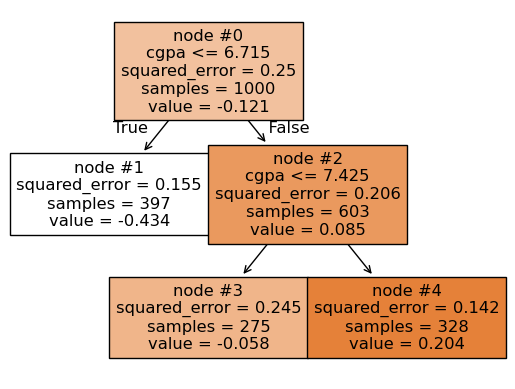

In [35]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plot_tree(reg1, feature_names=['cgpa','iq'],filled=True, node_ids=True)
plt.show()

In [36]:
df['leaf_entry1'] = reg1.apply(df.iloc[:,0:2])
df

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(


,cgpa,iq,is_placed,pre1(log-odds),pre1(probability),res1,leaf_entry1
0,7.34,101,1,0.510826,0.625,0.375,3
1,5.86,84,0,0.510826,0.625,-0.625,1
2,7.83,100,1,0.510826,0.625,0.375,4
3,8.03,114,1,0.510826,0.625,0.375,4
4,4.85,87,0,0.510826,0.625,-0.625,1
...,...,...,...,...,...,...,...
995,7.39,107,1,0.510826,0.625,0.375,3
996,7.84,109,0,0.510826,0.625,-0.625,4
997,7.13,100,0,0.510826,0.625,-0.625,3
998,7.14,94,0,0.510826,0.625,-0.625,3


In [37]:
def return_logs(leaf):
  temp_df = df[df['leaf_entry1'] == leaf]
  num = temp_df['res1'].sum()

  den = sum(temp_df['pre1(probability)'] * (1 - temp_df['pre1(probability)']))
  return round(num/den,2)

In [38]:
df['pre2(log-odds)'] = df['pre1(log-odds)'] + df['leaf_entry1'].apply(return_logs)

In [39]:
df['pre2(probability)'] = 1/(1+np.exp(-df['pre2(log-odds)']))
df

,cgpa,iq,is_placed,pre1(log-odds),pre1(probability),res1,leaf_entry1,pre2(log-odds),pre2(probability)
0,7.34,101,1,0.510826,0.625,0.375,3,0.260826,0.564839
1,5.86,84,0,0.510826,0.625,-0.625,1,-1.339174,0.207646
2,7.83,100,1,0.510826,0.625,0.375,4,1.380826,0.799124
3,8.03,114,1,0.510826,0.625,0.375,4,1.380826,0.799124
4,4.85,87,0,0.510826,0.625,-0.625,1,-1.339174,0.207646
...,...,...,...,...,...,...,...,...,...
995,7.39,107,1,0.510826,0.625,0.375,3,0.260826,0.564839
996,7.84,109,0,0.510826,0.625,-0.625,4,1.380826,0.799124
997,7.13,100,0,0.510826,0.625,-0.625,3,0.260826,0.564839
998,7.14,94,0,0.510826,0.625,-0.625,3,0.260826,0.564839


In [40]:
df['res2'] = df['is_placed'] - df['pre2(probability)']
df

,cgpa,iq,is_placed,pre1(log-odds),pre1(probability),res1,leaf_entry1,pre2(log-odds),pre2(probability),res2
0,7.34,101,1,0.510826,0.625,0.375,3,0.260826,0.564839,0.435161
1,5.86,84,0,0.510826,0.625,-0.625,1,-1.339174,0.207646,-0.207646
2,7.83,100,1,0.510826,0.625,0.375,4,1.380826,0.799124,0.200876
3,8.03,114,1,0.510826,0.625,0.375,4,1.380826,0.799124,0.200876
4,4.85,87,0,0.510826,0.625,-0.625,1,-1.339174,0.207646,-0.207646
...,...,...,...,...,...,...,...,...,...,...
995,7.39,107,1,0.510826,0.625,0.375,3,0.260826,0.564839,0.435161
996,7.84,109,0,0.510826,0.625,-0.625,4,1.380826,0.799124,-0.799124
997,7.13,100,0,0.510826,0.625,-0.625,3,0.260826,0.564839,-0.564839
998,7.14,94,0,0.510826,0.625,-0.625,3,0.260826,0.564839,-0.564839


In [41]:
reg2 = DecisionTreeRegressor(max_leaf_nodes=3, random_state=1)

reg2.fit(df.iloc[:,0:2].values, df.iloc[:,-1].values)

DecisionTreeRegressor(max_leaf_nodes=3, random_state=1)

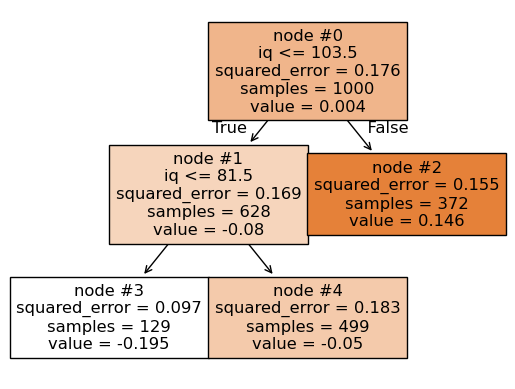

In [42]:
plot_tree(reg2, feature_names=['cgpa','iq'],filled=True, node_ids=True)
plt.show()

In [43]:
df['leaf_entry2'] = reg2.apply(df.iloc[:,0:2])
df

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(


,cgpa,iq,is_placed,pre1(log-odds),pre1(probability),res1,leaf_entry1,pre2(log-odds),pre2(probability),res2,leaf_entry2
0,7.34,101,1,0.510826,0.625,0.375,3,0.260826,0.564839,0.435161,4
1,5.86,84,0,0.510826,0.625,-0.625,1,-1.339174,0.207646,-0.207646,4
2,7.83,100,1,0.510826,0.625,0.375,4,1.380826,0.799124,0.200876,4
3,8.03,114,1,0.510826,0.625,0.375,4,1.380826,0.799124,0.200876,2
4,4.85,87,0,0.510826,0.625,-0.625,1,-1.339174,0.207646,-0.207646,4
...,...,...,...,...,...,...,...,...,...,...,...
995,7.39,107,1,0.510826,0.625,0.375,3,0.260826,0.564839,0.435161,2
996,7.84,109,0,0.510826,0.625,-0.625,4,1.380826,0.799124,-0.799124,2
997,7.13,100,0,0.510826,0.625,-0.625,3,0.260826,0.564839,-0.564839,4
998,7.14,94,0,0.510826,0.625,-0.625,3,0.260826,0.564839,-0.564839,4


In [44]:
def return_logs(leaf):
  num = df[df['leaf_entry2'] == leaf]['res2'].sum()
  den = sum(df[df['leaf_entry2'] == leaf]['pre2(probability)'] * (1 - df[df['leaf_entry2'] == leaf]['pre2(probability)']))
  return round(num/den,2)

In [45]:
df['pre3(log-odds)'] = df['pre1(log-odds)'] + df['pre2(log-odds)'] + df['leaf_entry2'].apply(return_logs)

In [46]:
df['pre3(probability)'] = 1/(1+np.exp(-df['pre3(log-odds)']))
df

,cgpa,iq,is_placed,pre1(log-odds),pre1(probability),res1,leaf_entry1,pre2(log-odds),pre2(probability),res2,leaf_entry2,pre3(log-odds),pre3(probability)
0,7.34,101,1,0.510826,0.625,0.375,3,0.260826,0.564839,0.435161,4,0.501651,0.622847
1,5.86,84,0,0.510826,0.625,-0.625,1,-1.339174,0.207646,-0.207646,4,-1.098349,0.250049
2,7.83,100,1,0.510826,0.625,0.375,4,1.380826,0.799124,0.200876,4,1.621651,0.835023
3,8.03,114,1,0.510826,0.625,0.375,4,1.380826,0.799124,0.200876,2,2.681651,0.935935
4,4.85,87,0,0.510826,0.625,-0.625,1,-1.339174,0.207646,-0.207646,4,-1.098349,0.250049
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,7.39,107,1,0.510826,0.625,0.375,3,0.260826,0.564839,0.435161,2,1.561651,0.826590
996,7.84,109,0,0.510826,0.625,-0.625,4,1.380826,0.799124,-0.799124,2,2.681651,0.935935
997,7.13,100,0,0.510826,0.625,-0.625,3,0.260826,0.564839,-0.564839,4,0.501651,0.622847
998,7.14,94,0,0.510826,0.625,-0.625,3,0.260826,0.564839,-0.564839,4,0.501651,0.622847


In [47]:
df['res3'] = df['is_placed'] - df['pre3(probability)']

df[['res1','res2','res3']]

,res1,res2,res3
0,0.375,0.435161,0.377153
1,-0.625,-0.207646,-0.250049
2,0.375,0.200876,0.164977
3,0.375,0.200876,0.064065
4,-0.625,-0.207646,-0.250049
...,...,...,...
995,0.375,0.435161,0.173410
996,-0.625,-0.799124,-0.935935
997,-0.625,-0.564839,-0.622847
998,-0.625,-0.564839,-0.622847


### Stage 4: Training another Decision Tree (`reg3`)

In [48]:
reg3 = DecisionTreeRegressor(max_leaf_nodes=3, random_state=1)
reg3.fit(df.iloc[:,0:2].values, df['res3'].values)

DecisionTreeRegressor(max_leaf_nodes=3, random_state=1)

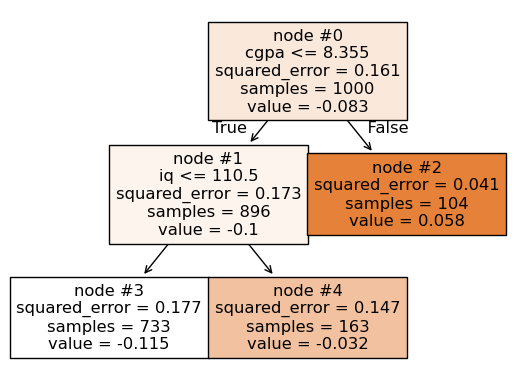

In [49]:
plot_tree(reg3, feature_names=['cgpa','iq'],filled=True, node_ids=True)
plt.show()

### Calculating Leaf Entries for `reg3`

In [50]:
df['leaf_entry3'] = reg3.apply(df.iloc[:,0:2])
df

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(


,cgpa,iq,is_placed,pre1(log-odds),pre1(probability),res1,leaf_entry1,pre2(log-odds),pre2(probability),res2,leaf_entry2,pre3(log-odds),pre3(probability),res3,leaf_entry3
0,7.34,101,1,0.510826,0.625,0.375,3,0.260826,0.564839,0.435161,4,0.501651,0.622847,0.377153,3
1,5.86,84,0,0.510826,0.625,-0.625,1,-1.339174,0.207646,-0.207646,4,-1.098349,0.250049,-0.250049,3
2,7.83,100,1,0.510826,0.625,0.375,4,1.380826,0.799124,0.200876,4,1.621651,0.835023,0.164977,3
3,8.03,114,1,0.510826,0.625,0.375,4,1.380826,0.799124,0.200876,2,2.681651,0.935935,0.064065,4
4,4.85,87,0,0.510826,0.625,-0.625,1,-1.339174,0.207646,-0.207646,4,-1.098349,0.250049,-0.250049,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,7.39,107,1,0.510826,0.625,0.375,3,0.260826,0.564839,0.435161,2,1.561651,0.826590,0.173410,3
996,7.84,109,0,0.510826,0.625,-0.625,4,1.380826,0.799124,-0.799124,2,2.681651,0.935935,-0.935935,3
997,7.13,100,0,0.510826,0.625,-0.625,3,0.260826,0.564839,-0.564839,4,0.501651,0.622847,-0.622847,3
998,7.14,94,0,0.510826,0.625,-0.625,3,0.260826,0.564839,-0.564839,4,0.501651,0.622847,-0.622847,3


In [51]:
def return_logs_stage3(leaf):
  num = df[df['leaf_entry3'] == leaf]['res3'].sum()
  den = sum(df[df['leaf_entry3'] == leaf]['pre3(probability)'] * (1 - df[df['leaf_entry3'] == leaf]['pre3(probability)']))
  return round(num/den,2)

In [52]:
df['pre4(log-odds)'] = df['pre3(log-odds)'] + df['leaf_entry3'].apply(return_logs_stage3)

In [53]:
df['pre4(probability)'] = 1/(1+np.exp(-df['pre4(log-odds)']))
df

,cgpa,iq,is_placed,pre1(log-odds),pre1(probability),res1,leaf_entry1,pre2(log-odds),pre2(probability),res2,leaf_entry2,pre3(log-odds),pre3(probability),res3,leaf_entry3,pre4(log-odds),pre4(probability)
0,7.34,101,1,0.510826,0.625,0.375,3,0.260826,0.564839,0.435161,4,0.501651,0.622847,0.377153,3,-0.148349,0.462981
1,5.86,84,0,0.510826,0.625,-0.625,1,-1.339174,0.207646,-0.207646,4,-1.098349,0.250049,-0.250049,3,-1.748349,0.148256
2,7.83,100,1,0.510826,0.625,0.375,4,1.380826,0.799124,0.200876,4,1.621651,0.835023,0.164977,3,0.971651,0.725449
3,8.03,114,1,0.510826,0.625,0.375,4,1.380826,0.799124,0.200876,2,2.681651,0.935935,0.064065,4,2.451651,0.920682
4,4.85,87,0,0.510826,0.625,-0.625,1,-1.339174,0.207646,-0.207646,4,-1.098349,0.250049,-0.250049,3,-1.748349,0.148256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,7.39,107,1,0.510826,0.625,0.375,3,0.260826,0.564839,0.435161,2,1.561651,0.826590,0.173410,3,0.911651,0.713338
996,7.84,109,0,0.510826,0.625,-0.625,4,1.380826,0.799124,-0.799124,2,2.681651,0.935935,-0.935935,3,2.031651,0.884080
997,7.13,100,0,0.510826,0.625,-0.625,3,0.260826,0.564839,-0.564839,4,0.501651,0.622847,-0.622847,3,-0.148349,0.462981
998,7.14,94,0,0.510826,0.625,-0.625,3,0.260826,0.564839,-0.564839,4,0.501651,0.622847,-0.622847,3,-0.148349,0.462981


In [54]:
df['res_final'] = df['is_placed'] - df['pre4(probability)']
df[['res1','res2','res3','res_final']]

,res1,res2,res3,res_final
0,0.375,0.435161,0.377153,0.537019
1,-0.625,-0.207646,-0.250049,-0.148256
2,0.375,0.200876,0.164977,0.274551
3,0.375,0.200876,0.064065,0.079318
4,-0.625,-0.207646,-0.250049,-0.148256
...,...,...,...,...
995,0.375,0.435161,0.173410,0.286662
996,-0.625,-0.799124,-0.935935,-0.884080
997,-0.625,-0.564839,-0.622847,-0.462981
998,-0.625,-0.564839,-0.622847,-0.462981


### Calculate Training Accuracy

In [56]:
from sklearn.metrics import accuracy_score

final_predictions = (df['pre4(probability)'] >= 0.5).astype(int)
accuracy = accuracy_score(df['is_placed'], final_predictions)

print(f"Training Accuracy of the final model: {accuracy:.4f}")

Training Accuracy of the final model: 0.7680


### Extracting Log-Odds Corrections from Training Data

In [57]:
# Extract correction for reg1 (applied through return_logs to pre1(log-odds))
df['reg1_correction'] = df['pre2(log-odds)'] - df['pre1(log-odds)']
leaf1_corrections = df.groupby('leaf_entry1')['reg1_correction'].first().to_dict()
print(f"Leaf 1 corrections: {leaf1_corrections}")

df['reg2_correction'] = df['pre3(log-odds)'] - df['pre2(log-odds)']
leaf2_corrections = df.groupby('leaf_entry2')['reg2_correction'].first().to_dict()
print(f"Leaf 2 corrections: {leaf2_corrections}")


df['reg3_correction'] = df['pre4(log-odds)'] - df['pre3(log-odds)']
leaf3_corrections = df.groupby('leaf_entry3')['reg3_correction'].first().to_dict()
print(f"Leaf 3 corrections: {leaf3_corrections}")

Leaf 1 corrections: {1: -1.85, 3: -0.25, 4: 0.8699999999999999}
Leaf 2 corrections: {2: 1.3008256237659905, 3: -0.5691743762340093, 4: 0.2408256237659907}
Leaf 3 corrections: {2: 0.69, 3: -0.65, 4: -0.22999999999999998}


### Prediction Function for a New Data Point

In [59]:
def predict_placement(cgpa, iq):
  # Create a DataFrame for the single data point
  test_data = pd.DataFrame({'cgpa': [cgpa], 'iq': [iq]})

  # Initial log-odds (from pre1)
  initial_log_odds = np.log(5/3)

  # Stage 1 prediction
  leaf_entry1_test = reg1.apply(test_data[['cgpa', 'iq']])[0]
  correction1 = leaf1_corrections.get(leaf_entry1_test, 0) # Use .get with default 0 if leaf not found
  current_log_odds = initial_log_odds + correction1

  # Stage 2 prediction
  leaf_entry2_test = reg2.apply(test_data[['cgpa', 'iq']])[0]
  correction2 = leaf2_corrections.get(leaf_entry2_test, 0)
  current_log_odds += correction2

  # Stage 3 prediction
  leaf_entry3_test = reg3.apply(test_data[['cgpa', 'iq']])[0]
  correction3 = leaf3_corrections.get(leaf_entry3_test, 0)
  current_log_odds += correction3

  # Convert final log-odds to probability
  final_probability = 1 / (1 + np.exp(-current_log_odds))

  # Convert probability to binary prediction
  final_prediction = int(final_probability >= 0.5)

  return final_prediction, final_probability

# Test with an example data point
test_cgpa = 6.00
test_iq = 90
prediction, probability = predict_placement(test_cgpa, test_iq)

print(f"For CGPA={test_cgpa} and IQ={test_iq}:")
print(f"Predicted Probability of Placement: {probability:.4f}")
print(f"Predicted Placement: {'Yes' if prediction == 1 else 'No'}")

For CGPA=6.0 and IQ=90:
Predicted Probability of Placement: 0.1483
Predicted Placement: No


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
